In [1]:
import scanpy as sc
import torch
import numpy as np
import umap
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder


d:\GP\Notebooks\Scimilarity\Scimilarity-venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
adata = sc.read_h5ad(r"D:\GP\Notebooks\Scimilarity\Baron_Pancreas_Human_mix.h5ad")
print(adata)


AnnData object with n_obs × n_vars = 8569 × 16381
    obs: 'donor_id', 'cell_type', 'barcode', 'donor_batch'


In [3]:
from scimilarity.cell_embedding import CellEmbedding
model_path = r"D:\GP\Scimilarity_test\model\annotation_model_v1"
ce = CellEmbedding(model_path)


In [4]:
adata.layers["counts"] = adata.X.copy()


In [5]:
adata = adata[adata.obs["cell_type"] != "Other"].copy()
print(adata.obs["cell_type"].value_counts())
labels = adata.obs["cell_type"]
X = adata.X
print("Number of classes:", labels.nunique())

cell_type
beta                  2525
alpha                 2326
ductal                1077
acinar                 958
delta                  601
activated_stellate     284
gamma                  255
endothelial            252
quiescent_stellate     173
macrophage              55
mast                    25
epsilon                 18
schwann                 13
t_cell                   7
Name: count, dtype: int64
Number of classes: 14


In [6]:
from scimilarity.utils import align_dataset, lognorm_counts
adata = align_dataset(adata, ce.gene_order)
adata = lognorm_counts(adata)


In [7]:
X = adata.X  # sparse or dense is fine

embeddings = ce.get_embeddings(X)
# pass as column in adata
adata.obsm["X_emb"] = embeddings
print(embeddings.shape)


(8569, 128)


In [8]:
# save embeddings to project directory
adata.write_h5ad("D:/GP/Notebooks/Scimilarity/Baron_Pancreas_mix_embeddings.h5ad")


In [9]:
print(adata.obs['cell_type'])

human1_lib1.final_cell_0001                acinar
human1_lib1.final_cell_0002                acinar
human1_lib1.final_cell_0003                acinar
human1_lib1.final_cell_0004                acinar
human1_lib1.final_cell_0005                acinar
                                      ...        
human4_lib3.final_cell_0697    activated_stellate
human4_lib3.final_cell_0698                 alpha
human4_lib3.final_cell_0699                  beta
human4_lib3.final_cell_0700                  beta
human4_lib3.final_cell_0701                ductal
Name: cell_type, Length: 8569, dtype: category
Categories (14, object): ['acinar', 'activated_stellate', 'alpha', 'beta', ..., 'mast', 'quiescent_stellate', 'schwann', 't_cell']


In [10]:


from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# logistic regression with cross-validation

clf = LogisticRegression(max_iter=300, solver='lbfgs')

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
x = adata.obsm["X_emb"]
y = adata.obs["cell_type"] 
y_pred_lr = cross_val_predict(clf, x , y, cv=kf)

# knn with cross-validation
from sklearn.neighbors import KNeighborsClassifier
# knn
# train
knn = KNeighborsClassifier(n_neighbors=15,
    weights="distance",
    metric="cosine")
knn.fit(x, y)
# test
y_pred_knn = cross_val_predict(knn, x , y, cv=kf)



In [11]:
# print y_pred and check classes
print(np.unique(y_pred_lr))
print(np.unique(y_pred_knn))

['acinar' 'activated_stellate' 'alpha' 'beta' 'delta' 'ductal'
 'endothelial' 'gamma' 'macrophage' 'mast' 'quiescent_stellate' 'schwann'
 't_cell']
['acinar' 'activated_stellate' 'alpha' 'beta' 'delta' 'ductal'
 'endothelial' 'epsilon' 'gamma' 'macrophage' 'mast' 'quiescent_stellate'
 'schwann' 't_cell']


In [12]:
from sklearn.metrics import accuracy_score, classification_report

# Evaluate the model
print("Accuracy (Logistic Regression):", accuracy_score(y, y_pred_lr))
print("Classification Report (Logistic Regression):\n", classification_report(y, y_pred_lr, zero_division=0))

print("Accuracy (k-NN):", accuracy_score(y, y_pred_knn))
print("Classification Report (k-NN):\n", classification_report(y, y_pred_knn))

Accuracy (Logistic Regression): 0.936281946551523
Classification Report (Logistic Regression):
                     precision    recall  f1-score   support

            acinar       0.94      0.98      0.96       958
activated_stellate       0.94      0.96      0.95       284
             alpha       0.94      0.99      0.96      2326
              beta       0.91      0.99      0.95      2525
             delta       0.93      0.80      0.86       601
            ductal       0.98      0.94      0.96      1077
       endothelial       0.98      0.96      0.97       252
           epsilon       0.00      0.00      0.00        18
             gamma       0.88      0.16      0.28       255
        macrophage       0.98      0.89      0.93        55
              mast       0.96      0.96      0.96        25
quiescent_stellate       0.93      0.86      0.89       173
           schwann       1.00      0.31      0.47        13
            t_cell       1.00      0.43      0.60         7

  

In [13]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

def plot_cm(y_true, y_pred, title):
    labels = np.unique(y_true)
    cm = confusion_matrix(y_true, y_pred, labels=labels, normalize="true")

    fig, ax = plt.subplots(figsize=(10, 8), dpi=100)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=labels)

    disp.plot(
        ax=ax,
        cmap="Blues",
        xticks_rotation=90,
        values_format=".2f",
        colorbar=True
    )

    # Make text smaller
    for text in ax.texts:
        text.set_fontsize(7)

    plt.title(title, fontsize=16)
    plt.xlabel("Predicted label", fontsize=12)
    plt.ylabel("True label", fontsize=12)

    plt.tight_layout()
    plt.show()

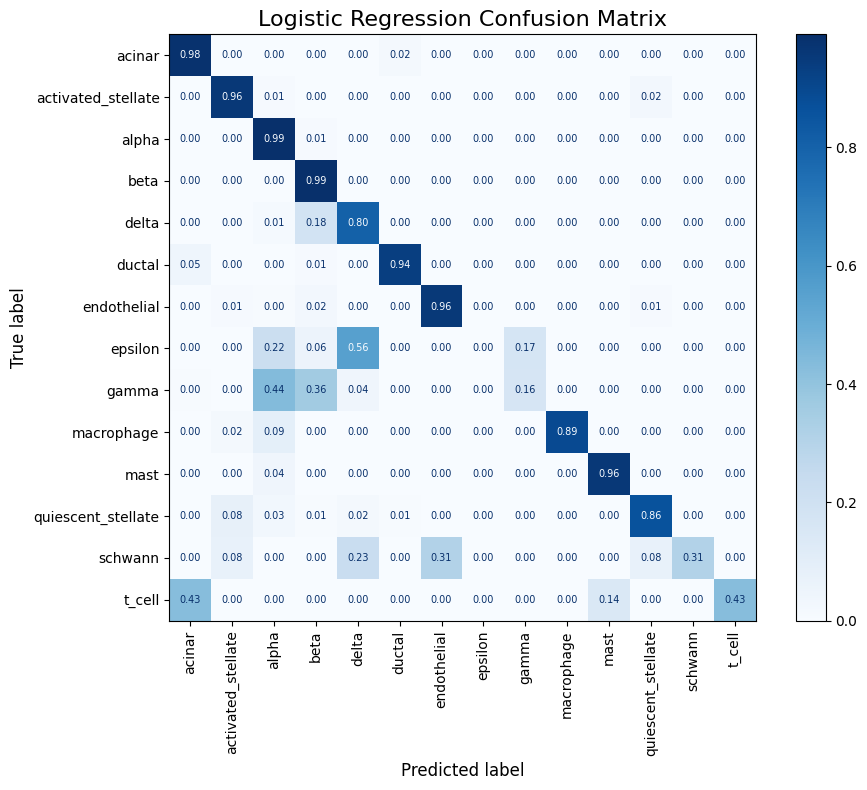

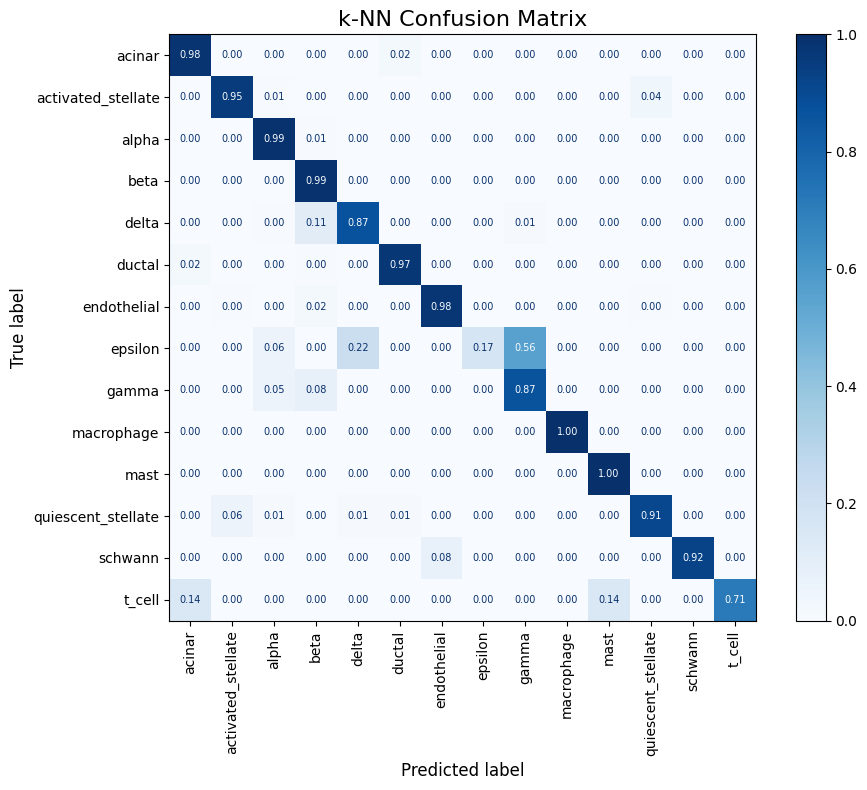

In [14]:
plot_cm(y, y_pred_lr, "Logistic Regression Confusion Matrix")
plot_cm(y, y_pred_knn, "k-NN Confusion Matrix")

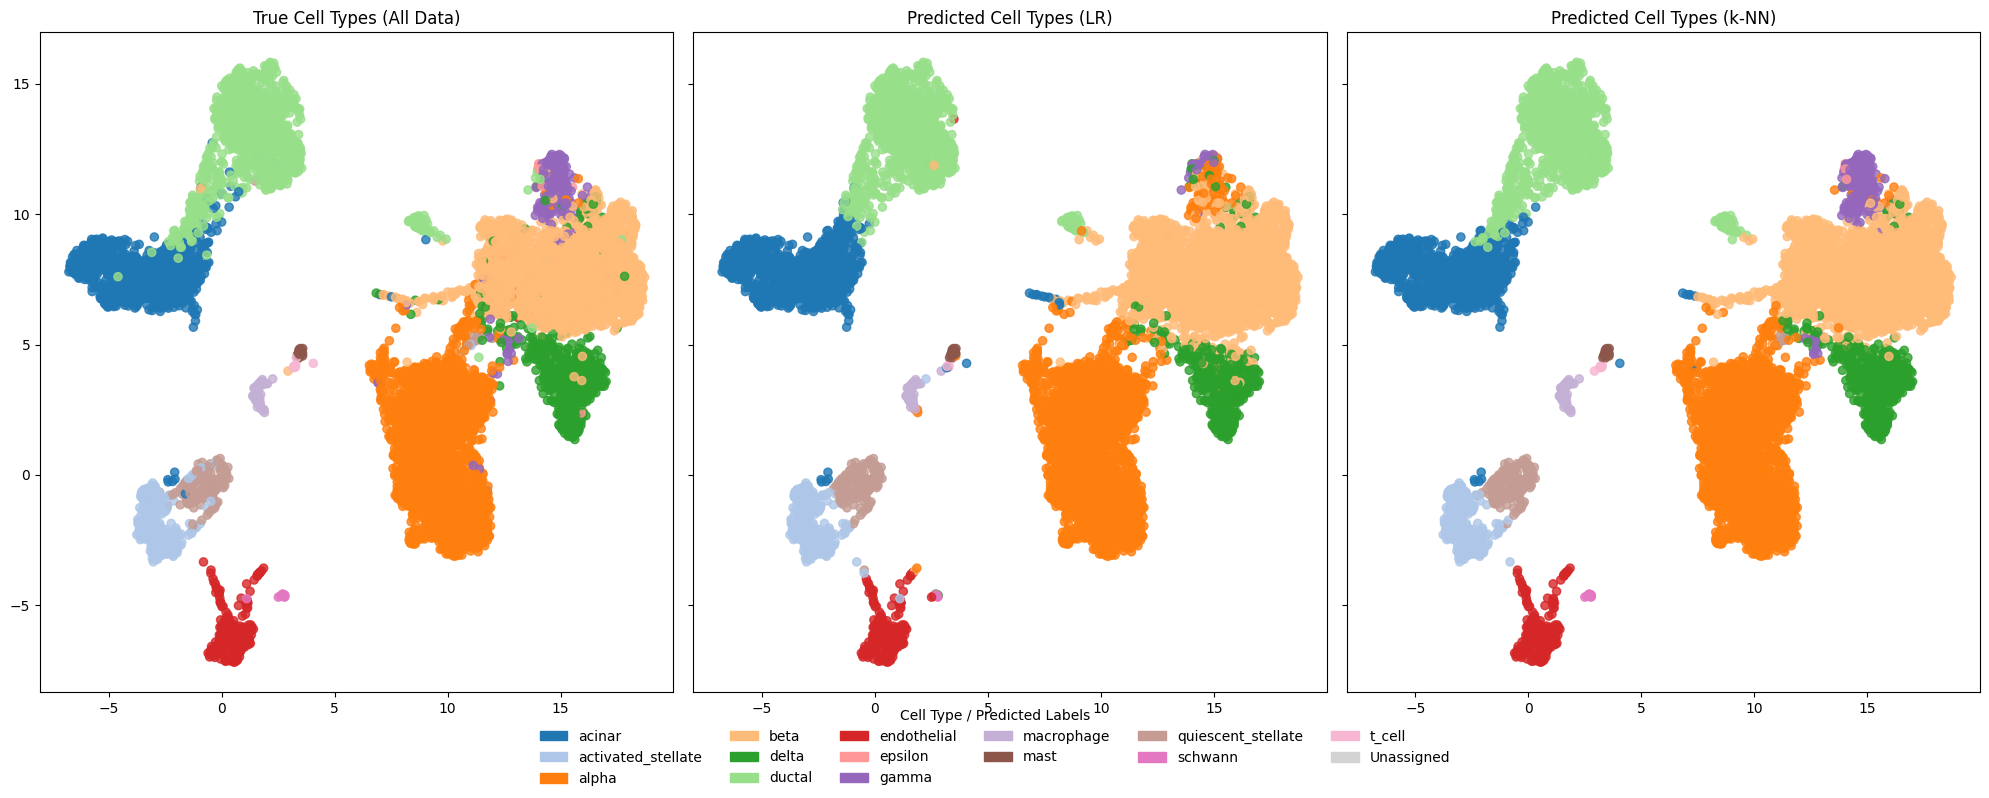

In [15]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import pandas as pd

# Fill missing predicted labels
adata.obs['y_pred_lr'] = pd.Series(y_pred_lr, index=adata.obs_names).astype(str).fillna('Unassigned')
adata.obs['y_pred_knn'] = pd.Series(y_pred_knn, index=adata.obs_names).astype(str).fillna('Unassigned')

# PCA + neighbors + UMAP on full data
sc.pp.neighbors(adata, use_rep='X_emb', n_neighbors=15)
sc.tl.umap(adata)


# # Subset predicted cells only
# test_adata = adata[adata.obs['y_pred'] != 'Unassigned'].copy()

# Unified label categories
all_labels = pd.Categorical(pd.concat([
    pd.Series(adata.obs['cell_type'].cat.categories),
    pd.Series(pd.Categorical(adata.obs['y_pred_lr']).categories),
    pd.Series(pd.Categorical(adata.obs['y_pred_knn']).categories)
    
], ignore_index=True)).categories

# Color map
palette = sc.pl.palettes.vega_20
label_to_color = {lbl: palette[i % len(palette)] for i, lbl in enumerate(all_labels)}
label_to_color['Unassigned'] = 'lightgray'

# Add color columns to adata
adata.obs['color_true'] = adata.obs['cell_type'].map(label_to_color)
adata.obs['color_pred_lr'] = adata.obs['y_pred_lr'].map(label_to_color)
adata.obs['color_pred_knn'] = adata.obs['y_pred_knn'].map(label_to_color)
# Plot side by side
fig, axes = plt.subplots(1, 3, figsize=(20, 8), sharex=True, sharey=True)

axes[0].scatter(adata.obsm['X_umap'][:,0], adata.obsm['X_umap'][:,1],
                c=adata.obs['color_true'], s=35, alpha=0.8)
axes[0].set_title('True Cell Types (All Data)')

axes[1].scatter(adata.obsm['X_umap'][:,0], adata.obsm['X_umap'][:,1],
                c=adata.obs['color_pred_lr'], s=35, alpha=0.8)
axes[1].set_title('Predicted Cell Types (LR)')

axes[2].scatter(adata.obsm['X_umap'][:,0], adata.obsm['X_umap'][:,1],
                c=adata.obs['color_pred_knn'], s=35, alpha=0.8)
axes[2].set_title('Predicted Cell Types (k-NN)')

# Shared legend
handles = [Patch(color=color, label=lbl) for lbl, color in label_to_color.items()]
fig.legend(handles=handles, title='Cell Type / Predicted Labels', loc='lower center', ncol=6, frameon=False)



plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()
